# Assumption Testing
In this section we will test the variables the final grades of Portuguese and Mathematics (pG3 and mG3) for outliers, normality of distribution and homoskedasticity.

In [30]:
import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib.pyplot as plt
import math
import seaborn as sns

If we plot the distributions of pG3 and mG3 we can see that although they both look relatively normal, there appear to be some outliers. We will test this by comparing the distributions to a fitted normal pdf distribution.

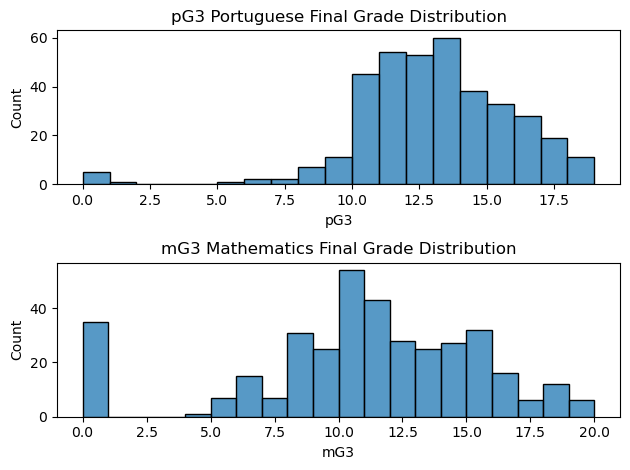

In [31]:
# Display the distributions of pG3 and mG3

df = pd.read_csv("prepared_dataset.csv") # load the csv file prepared in a2_data_description.ipynb
fig, ax = plt.subplots(2)

sns.histplot(data=df, x="pG3", binwidth=1, stat='count', ax=ax[0])
ax[0].set_title("pG3 Portuguese Final Grade Distribution")

sns.histplot(data=df, x="mG3", binwidth=1,stat='count', ax=ax[1])
ax[1].set_title("mG3 Mathematics Final Grade Distribution")

plt.tight_layout()


## Standardising the final grade variables for mathematics and portuguese

We will transform the values of the final maths and Portuguese grades (mG3 and pG3) such that the mean will be 0, and the standard deviation is 1. This will allow us to compare the distribution to the normal pdf distribution more easily.

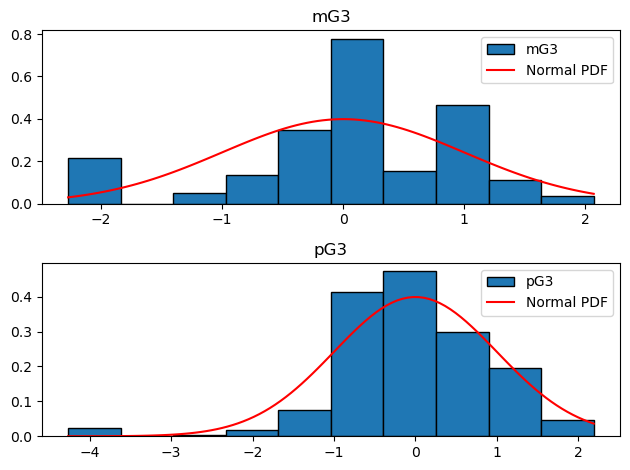

In [32]:
#Standardising the variables

#function to standardise and plot histogram and pdf
def plot_hist_and_norm_pdf(v, standardize=False, ax=ax):
    m = v.mean()
    s = v.std()
    
    if (standardize):
        v = (v - m)/s
        m = 0
        s = 1
        
    ax.hist(v, density=True, edgecolor='black', label=v.name)
    
    x = np.linspace(min(v), max(v), 100)
    ax.plot(x, ss.norm.pdf(x, loc=m, scale=s), 'r-', label="Normal PDF")
    ax.set_title(v.name)
    
    ax.legend()


fig, ax = plt.subplots(2)
plot_hist_and_norm_pdf(df["mG3"], standardize=True, ax=ax[0])
plot_hist_and_norm_pdf(df["pG3"], standardize=True, ax=ax[1])
plt.tight_layout()



# Testing for outliers

We will identify any outliers in our final grades for Portuguese (pG3) and Mathematics (mG3). 



In [33]:
print("Number of instances pG3:", len(df["pG3"]))
print("Number of instances mG3:",len(df["mG3"]))

Number of instances pG3: 370
Number of instances mG3: 370


In [34]:
# we will check the variable scaled to mean of 0 and standard deviation of 1
def identify_outliers(v):

    m = v.mean()
    s = v.std() 
    n = len(v)

    v_scaled = (v - m) / s

    # outlier standardised critical values, for n>80. 
    ocv = ss.norm.ppf(0.9995)

    # get any outliers
    outliers = v[abs(v_scaled) > ocv]

    print(outliers)
    return outliers

#print outlier index and value
print("mG3 outlier rows:")
mG3_outlier_rows = identify_outliers(df["mG3"])

print()

print("pG3 outlier rows:")
pG3_outlier_rows = identify_outliers(df["pG3"])

mG3 outlier rows:
Series([], Name: mG3, dtype: int64)

pG3 outlier rows:
236    1
319    0
341    0
358    0
360    0
369    0
Name: pG3, dtype: int64


No outliers were found in the standardsied mG3 values. All data points that seemed like outliers were not significantly far away from the rest of the distribution.

6 outlier instances were found in the standardised pG3. These were the students whose final grade in Portuguese was either 0 or 1, a very poor grade. 

In [35]:
#show pG3 outlier rows where the pG3 grade is 0 or 1
df[df["pG3"].isin([0,1])]

,Unnamed: 0,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,...,famrel,freetime,goout,Dalc,Walc,health,absences.p,pG1,pG2,pG3
236,238,GP,M,16,U,GT3,T,3,3,other,...,4,5,5,4,4,5,0,10,10,1
319,330,GP,M,18,U,LE3,T,1,1,other,...,2,3,5,2,5,4,0,11,9,0
341,352,MS,F,18,R,GT3,T,4,4,other,...,3,2,2,4,2,5,0,7,5,0
358,370,MS,M,18,R,GT3,T,2,1,other,...,4,4,3,1,3,5,0,7,7,0
360,372,MS,M,18,R,GT3,T,4,2,other,...,5,4,3,4,3,3,0,7,7,0
369,381,MS,M,19,R,GT3,T,1,1,other,...,4,3,2,1,3,5,0,5,8,0


#### Dealing with outliers in the dataset:

Although the outliers where students received a grade of 0 are possibly due to the student being absent on the day of the exam, it is acceptable to leave the outliers in the dataset as they may be informative based on other information and may reflect the circumstances of the students for reasons other than non-attendance. Other factors that are captured in the data may be able to explain why the student received the 0 grade. 

# Testing normality of distribution

We will perform a number of tests for normality:
1. Visual inspection
2. Skewness and kurtosis
3. Excessive spread of values
4. Goodness of fit tests

### 1. Visual Inspections
First, we will do a visual inspection to check for normality by plotting the distribution of the final grades against the normal ppf distribution to see how well they match.

We will also plot the normal q-q plot for both subject's final grades to see how well each distribution's quantiles balance themelves. 

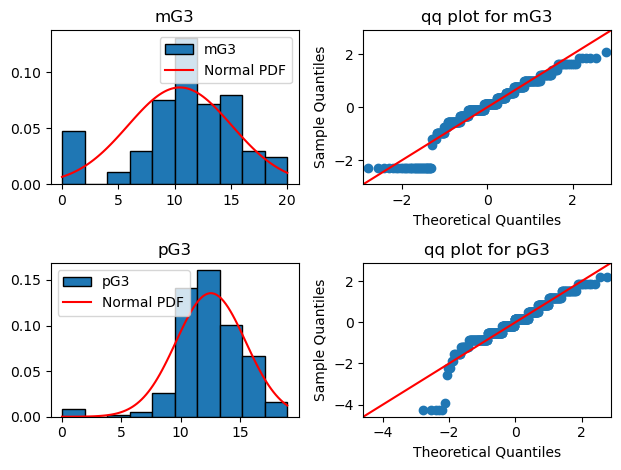

In [36]:
import statsmodels.api as sm

fig, ax = plt.subplots(2,2)

plot_hist_and_norm_pdf(df["mG3"], standardize=False, ax=ax[0][0])

sm.qqplot(df['mG3'], line='45', fit=True, ax=ax[0][1])
#plt.subplot(222)
#ss.probplot(df['mG3'], plot=plt)
ax[0][1].set_title("qq plot for mG3")

plot_hist_and_norm_pdf(df["pG3"], standardize=False, ax= ax[1][0])

#plt.subplot(224)
#ss.probplot(df['pG3'], plot=plt)
sm.qqplot(df['pG3'], line='45', fit=True, ax=ax[1][1])
ax[1][1].set_title("qq plot for pG3")

plt.tight_layout()
plt.show()

#### Visual inspection - Observations:
The qq plot of the final Portuguese grade does not look normal due to the outliers.

The qq plot of the final mathematics grade does not look completely normal due to the values around (-2,-2).

In both cases the non-normality is due to the outliers where students received particularly low grades. 


## 2. Skewness and Kurtosis

We will calculate the skewness and kurtosis values to check if the data is skewed to one side, or has thick or thin tails in a way that would suggest that the distribution is not normal.

We begin by calculating the skewness and kurtosis for the final grades in both subjects.

In [37]:
print("mG3")
print("Skewness: ", round(ss.skew(df["mG3"]), 3))
print("Kurtosis: ", round(ss.kurtosis(df["mG3"], fisher=True), 3))

print()

print("pG3")
print("Skewness: ", round(ss.skew(df["pG3"]), 3))
print("Kurtosis: ", round(ss.kurtosis(df["pG3"], fisher=True), 3))


mG3
Skewness:  -0.707
Kurtosis:  0.339

pG3
Skewness:  -1.009
Kurtosis:  3.585


### Interpreting Skewness and Kurtosis

Skewness and kurtosis scores, as calculated above, vary depending on the sample size. To evaluate the significance of the kurtosis and skewness, we can calculate the z-scores of a normal distribution and compare it to the critical value at the 95% confidence level.

In [38]:
#standard error skewness and kurtosis 
def se_skew(n):
    return math.sqrt(6*n*(n-1)/(n-2)/(n+1)/(n+3))
def se_kurt(n):
    return se_skew(n)*2*math.sqrt((n-1)*(n+1)/(n-3)/(n+5))

In [39]:
# pG3 and mG3 skewness and kurtosis z-values
pg3_skewness_z_score = round(ss.skew(df["pG3"])/se_skew(len(df["pG3"])), 3)
pg3_kurtosis_z_score = round(ss.kurtosis(df["pG3"], fisher=True)/se_kurt(len(df)), 3)

mg3_skewness_z_score = round(ss.skew(df["mG3"])/se_skew(len(df["mG3"])), 3)
mg3_kurtosis_z_score = round(ss.kurtosis(df["mG3"], fisher=True)/se_kurt(len(df)), 3)

conf_95pc = 1.96

def check_sig(z_score, conf_95pc, str):
    if abs(z_score) < conf_95pc:
        print(str+" at 95% confidence: non-significant ")
        return 0
    else:
        print(str+": non-normality ")
        return 1
    
print("pG3")
print("Skewness z-score:", pg3_skewness_z_score)
sig = check_sig(pg3_skewness_z_score, conf_95pc, "skewness")
print("Kurtosis z-score", pg3_kurtosis_z_score)
sig = check_sig(pg3_kurtosis_z_score, conf_95pc, "kurtosis")

print()

print("mG3")
print("Skewness z-score:", mg3_skewness_z_score)
sig = check_sig(mg3_skewness_z_score, conf_95pc, "skewness")
print("Kurtosis z-score", mg3_kurtosis_z_score)
sig = check_sig(mg3_kurtosis_z_score, conf_95pc, "kurtosis")


pG3
Skewness z-score: -7.953
skewness: non-normality 
Kurtosis z-score 14.172
kurtosis: non-normality 

mG3
Skewness z-score: -5.575
skewness: non-normality 
Kurtosis z-score 1.339
kurtosis at 95% confidence: non-significant 


#### Skewness and kurtosis observations
At a 95% confidence level, we can interpret our skewness and kurtosis scores by comparing them to $\pm$ 1.96. 

The skewness and kurtosis z-scores of the portuguese final grade falls outside the 95% confidence interval and indicate that the distribution is not normal.

The skewness z-score of the final maths grade indicates that the values of the Maths grades are not normal. 

### 3. Excessive spread of values

We will check what percentage of values for mG3 and pG3 lie over 2 standard deviations from the mean. If a large amount of our values are far from the mean we will know that the distribution is not likely to be normal.

In [40]:
def pc_over_2sd(v):
    m = v.mean()
    s = v.std()
    return sum((v > (m + 2 * s)) | (v < (m - 2 * v)))/len(v)*100

mg3_pc = pc_over_2sd(df["mG3"])
pg3_pc = pc_over_2sd(df["pG3"])

print("mG3 % over 2 standard dev from mean:", round(mg3_pc,2),"%")
print("pG3 % over 2 standard dev from mean:", round(pg3_pc,2),"%")

mG3 % over 2 standard dev from mean: 9.73 %
pG3 % over 2 standard dev from mean: 2.16 %


Excessive spread of values - Observations:

mG3 has 9.73% of its values over 2 standard deviations from the mean. This is over the 5% threshold above which the distribution is not considered normal.

In contrast, pG3 has only 2.16% values over 2 standard deviations from the mean.

### 4. Goodness of fit tests

The goodness of fit tests measure how well our distribution fits a normal distribution.
They are not always reliable.

We will use the following goodness of fit tests on the dataset:
- Shapiro-Wilks
- Kolmogorov-Smirnov 1 sample test:


In [41]:
# shapiro-Wilks and Kolmogorov-Smirnov goodness of fit tests

#mG3
mg3_sw = ss.shapiro(df["mG3"])
mg3_ks = ss.ks_1samp(df["mG3"], ss.norm.cdf)

#pG3
pg3_sw = ss.shapiro(df["pG3"])
pg3_ks = ss.ks_1samp(df["pG3"], ss.norm.cdf)

def check_normal(test_result, test_name):
    if(test_result.statistic < test_result.pvalue):
        print(f"{test_name} - Not significant: {test_result.statistic} < {test_result.pvalue}")
    else:
        print(f"{test_name} - Not normal: {test_result.statistic} > {test_result.pvalue}")

print("mG3 Shapiro-Wilks: ", mg3_sw)
check_normal(mg3_sw, "Shapiro-Wilks")
print("mG3 Kolmogorov-Smirnov: ", mg3_ks)
check_normal(mg3_sw, "Kolmogorov-Smirnov")
print()
print("pG3 Shapiro-Wilks: ", pg3_sw)
check_normal(pg3_sw, "Shapiro-Wilks")
print("pG3 Kolmogorov-Smirnov: ", pg3_ks)
check_normal(pg3_sw, "Kolmogorov-Smirnov")



mG3 Shapiro-Wilks:  ShapiroResult(statistic=0.9315041303634644, pvalue=5.321305028560541e-12)
Shapiro-Wilks - Not normal: 0.9315041303634644 > 5.321305028560541e-12
mG3 Kolmogorov-Smirnov:  KstestResult(statistic=0.9053737341635723, pvalue=0.0, statistic_location=4, statistic_sign=-1)
Kolmogorov-Smirnov - Not normal: 0.9315041303634644 > 5.321305028560541e-12

pG3 Shapiro-Wilks:  ShapiroResult(statistic=0.9208469390869141, pvalue=4.653714479746496e-13)
Shapiro-Wilks - Not normal: 0.9208469390869141 > 4.653714479746496e-13
pG3 Kolmogorov-Smirnov:  KstestResult(statistic=0.9837834971322119, pvalue=0.0, statistic_location=5, statistic_sign=-1)
Kolmogorov-Smirnov - Not normal: 0.9208469390869141 > 4.653714479746496e-13


The Shapiro-Wilks and Kolmogorov-Smirnov tests indicate a significant difference from normal for both the maths and portuguese final grades.

### Summary of normality tests

|Test|Maths final grade mG3|Portuguese Final Grade pG3|
|--|--|--|
|Visual|non-normal| non-normal|
|Kurtosis|-|non-normal|
|Skewness|non-normal|non-normal|
|Excessive spread|non-normal|-|
|Shapiro-Wilks|non-normal|non-normal|
|Kolmogorov-Smirnov|non-normal|non-normal|

Most of our tests indicate that both final grades have a non-normal distribution.

# Testing for homoskedasticity

In the [Analysis Design](a1_analysis_design.ipynb) section we hypothesised that:
> Students who drink alcohol more frequently during the week are associated with worse grades.

Our dependent variables are mG3 and pG3. The independent variable is **Dalc**, which represents the weekday alcohol consumption on an ordinal scale from 1, very low weekday alcohol consumption, to 5, very high weekday alcohol consumption.

We will test for homoskedasticity to see if the variances in the grades are equal across the 5 categories of weekday alcohol consumption from 1, very low weekday alcohol consumption to 5, very high.

Text(0.5, 1.0, 'Weekday alcohol consumption vs pG3 Portuguese grade')

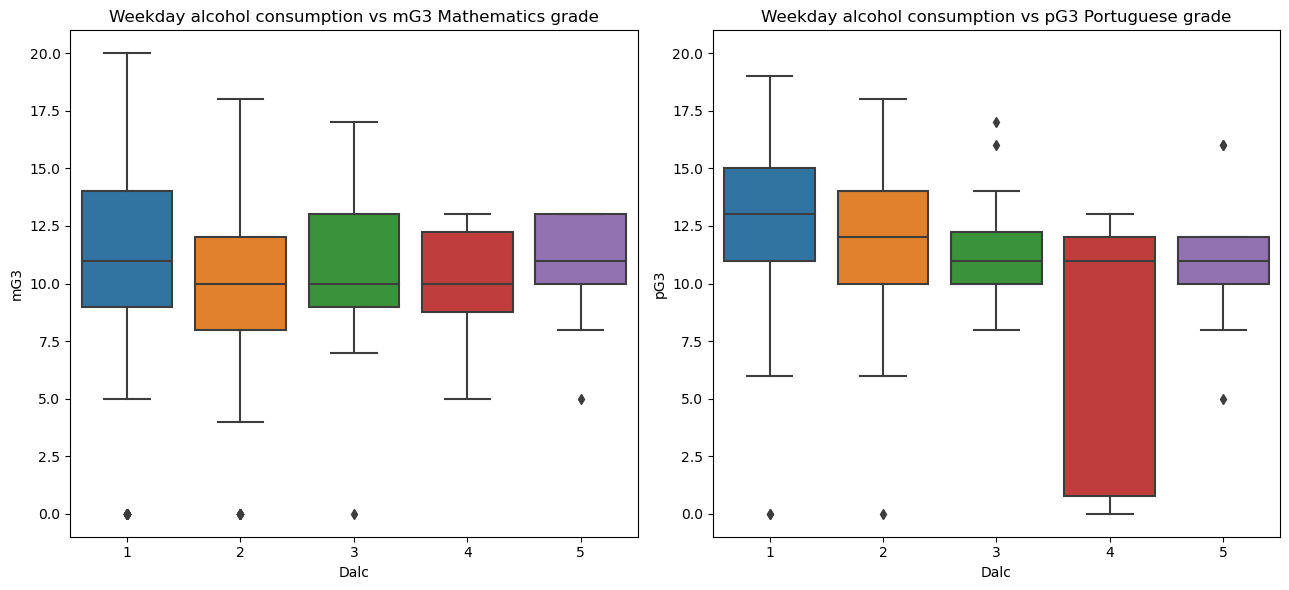

In [42]:
#Box plot of weekday alcohol consumption Dalc and grades

plt.figure(figsize=(13,6), tight_layout=True)
ax1 = plt.subplot(121)
sns.boxplot(data=df, x="Dalc", y="mG3")
plt.title("Weekday alcohol consumption vs mG3 Mathematics grade")

ax2= plt.subplot(122,  sharey=ax1, sharex=ax1)
sns.boxplot(data=df, x="Dalc", y="pG3")
plt.title("Weekday alcohol consumption vs pG3 Portuguese grade")

From the box plots it appears that there is a much wider range of grades when weekday alcohol is lower, compared to a narrower range when weekday alcohol consumption is higher.
This applies to both the Maths and Portuguese grades and suggests that there is low homoskedasticity in this case.

Next, we will perform Bartlett's test and Levene's test for homoskedasticity.

In [43]:
# Bartlett test for homoskedasticity
pg3_bartlett = ss.bartlett(*[df['pG3'][df["Dalc"] == cat] for cat in df["Dalc"].unique()])
mg3_bartlett = ss.bartlett(*[df['mG3'][df["Dalc"] == cat] for cat in df["Dalc"].unique()])

print("mG3 Bartlett:", mg3_bartlett)
print("pG3 Bartlett:", pg3_bartlett)


mG3 Bartlett: BartlettResult(statistic=9.231701916516865, pvalue=0.05556188520707724)
pG3 Bartlett: BartlettResult(statistic=19.169815269747414, pvalue=0.0007278042332041956)


The Bartlett test on the Mathematics final grade(p=.056) suggests that there is no evidence of heteroskedasticity and therefore the variance between groups can be considered homoskedastic.

The test on the final Portuguese grade (p<.001) means that the null hypothesis can be rejected and the distribution of the variances is considered heteroskedastic.


In [44]:
#Levene test for homoskedasticity
mg3_levene= ss.levene(*[df['mG3'][df["Dalc"] == cat] for cat in df["Dalc"].unique()])
pg3_levene = ss.levene(*[df['pG3'][df["Dalc"] == cat] for cat in df["Dalc"].unique()])

print("mG3 Levene:", mg3_levene)

print("pG3 Levene:", pg3_levene)


mG3 Levene: LeveneResult(statistic=1.6655198579626498, pvalue=0.15738193223305233)
pG3 Levene: LeveneResult(statistic=3.9012535107238118, pvalue=0.004077364400013538)


Levene's test is more robust when the distribution is not normal. 

The test on the weekday alcohol consumption by Portuguese final grade (p =.004) indicates that at the 95% confidence level the null hypothesis that there is no difference in the variances can be rejected, meaning that the distribution of the variances can be considered heteroskedastic. 

The test on the weekday alcohol consumption Mathematics final grade (p=.157) falls outside the 95% level of confidence and means the null hypothesis fails to be rejected, meaning the distribution is homoskedastic.

The results of Levene's test match with the results found in the Bartlett test. They show that variance of the frequency of alcohol consumption relative to the Mathematics final grade is not significant, but for the Portuguese final grade it is.

## Conclusions:

The data for the Portuguese final grades, pG3, contained some outliers and was is not normally distributed with the outliers left in the dataset.

The Mathematics data did not appear to contain outliers, but the distribution did not appear to be normal from our normality tests.

We considered our initial hypothesis that 
> Students who drink alcohol more frequently during the week are associated with worse grades.

We tested both final grades mG3 and pG3 in association with the frequency of weekday alcohol consumption (Dalc) for homoskedasticity. We found that the variances within the Mathematics final grade were homoskedastic, and the variances within the Portuguese final grade were not homoskedastic when the variances of weekday alcohol consumption were considered. 